In [26]:
import numpy as np
import pandas as pd


In [27]:
df=pd.read_csv("/content/drive/MyDrive/MLT/EEG_Eye_State_Classification.csv")
df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [28]:
df.isnull()
df.isnull().sum()

,0
AF3,0
F7,0
F3,0
FC5,0
T7,0
P7,0
O1,0
O2,0
P8,0
T8,0


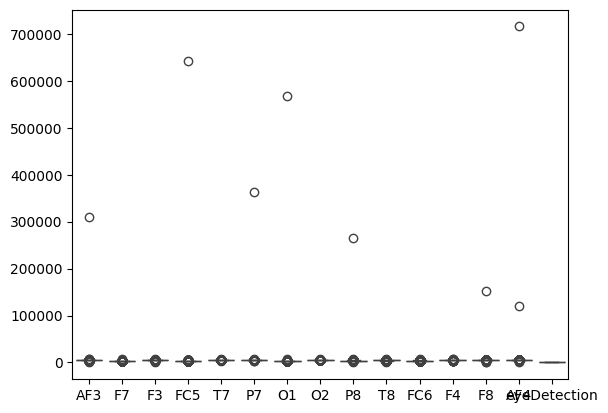

In [29]:
#outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.show()

In [30]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR= Q3-Q1
outliers = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [31]:
x=df.drop('eyeDetection',axis=1)
y=df['eyeDetection']

In [32]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000

)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [35]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix",cm)

report=classification_report(y_test,y_pred)
print("Classification Report",report)

Accuracy: 0.6275033377837116
Confusion Matrix [[1240  346]
 [ 770  640]]
Classification Report               precision    recall  f1-score   support

           0       0.62      0.78      0.69      1586
           1       0.65      0.45      0.53      1410

    accuracy                           0.63      2996
   macro avg       0.63      0.62      0.61      2996
weighted avg       0.63      0.63      0.62      2996

